# **1. PERUMUSAN MASALAH DAN DATASET**

Tujuan Analisis : Proses persetujuan pinjaman merupakan keputusan penting bagi lembaga keuangan karena berkaitan dengan risiko kredit.

**SUMBER DATA**

Loan Approval Prediction Dataset

Data ini berasal dari kaggle





In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('loan_approval_dataset.xlsx')

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df = df.drop(columns=['loan_id'])

# **2. EDA**

a. Membuat Statistik Deskriptif

In [ ]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.describe(include='object')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


b. Memvisualisasikan Data

Bar Chart

[' Graduate' ' Not Graduate']


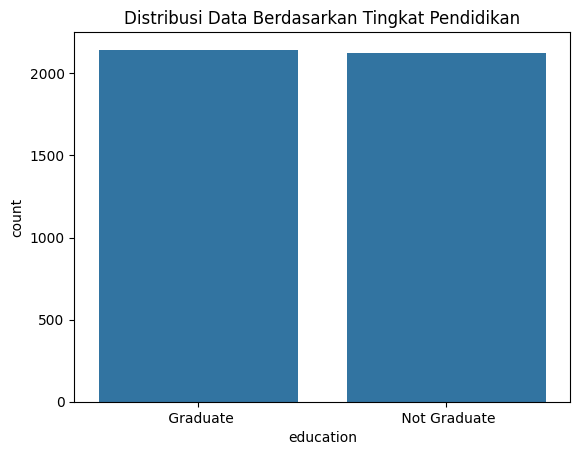

In [ ]:
df.columns = df.columns.str.strip()

#Menampilkan nilai unik dalam kolom education
unique_values = df['education'].unique()
print(unique_values)

#Analisis Distribusi Kategori
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='education', data=df)
plt.title('Distribusi Data Berdasarkan Tingkat Pendidikan')

plt.show()

**INTERPRETASI**

Dari barchart terlihat jumlah pemohon dengan pendidikan Graduate sedikit lebih banyak dibandingkan Not Graduate. Namun perbedaannya tidak terlalu jauh sehingga distribusi data berdasarkan tingkat pendidikan dapat dianggap seimbang.

[' Approved' ' Rejected']


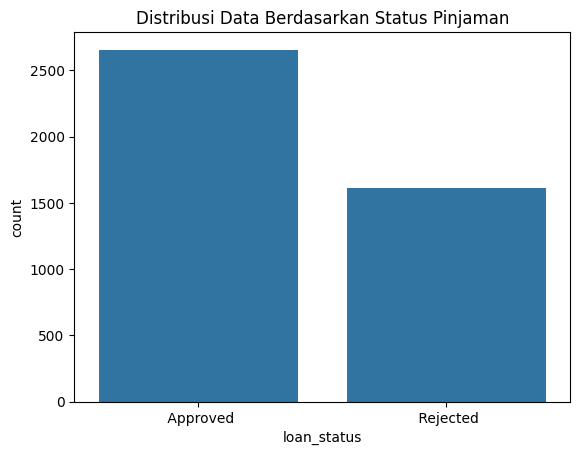

In [ ]:
# Menampilkan nilai unik dalam kolom loan_status
unique_values = df['loan_status'].unique()
print(unique_values)

# Analisis Distribusi Kategori
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status', data=df)
plt.title('Distribusi Data Berdasarkan Status Pinjaman')

plt.show()

**INTERPRETASI**

Dari barchart terlihat jumlah data dengan status pinjaman Approved lebih banyak dibandingkan Rejected. Perbedaannya cukup jauh sehingga distribusi data berdasarkan status pinjaman tidak seimbang.

Histogram

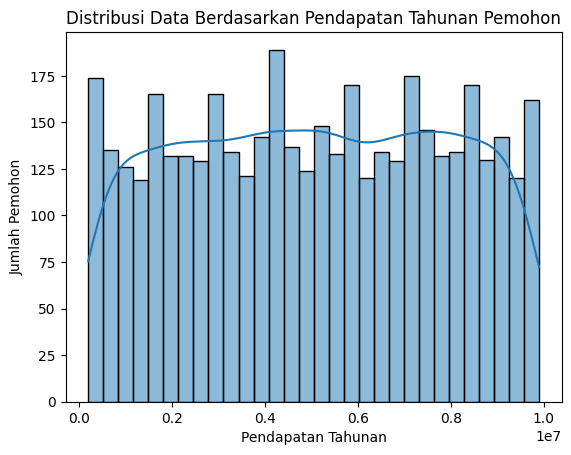

In [ ]:
# Histogram berdasarkan Pendapatan Tahunan
sns.histplot(data=df, x='income_annum', bins=30, kde=True)
plt.title('Distribusi Data Berdasarkan Pendapatan Tahunan Pemohon')
plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Jumlah Pemohon')
plt.show()

**INTERPRETASI**

Berdasarkan histogram, terlihat bahwa pendapatan tahunan pemohon tersebar pada berbagai rentang pendapatan dengan jumlah yang relatif merata. Tidak terdapat satu rentang pendapatan tertentu yang sangat mendominasi dibandingkan rentang lainnya.

Pola distribusi ini menunjukkan bahwa data pendapatan tahunan tidak mengikuti distribusi normal yang jelas. Sebaran data cukup luas dan mencakup pemohon dengan pendapatan rendah hingga tinggi, sehingga dataset mampu merepresentasikan berbagai kondisi ekonomi pemohon pinjaman.

Dalam konteks analisis persetujuan pinjaman, variabel income_annum penting untuk diperhatikan karena pendapatan tahunan dapat memengaruhi kemampuan pemohon dalam memenuhi kewajiban pembayaran pinjaman. Pemohon dengan pendapatan yang lebih tinggi cenderung memiliki kemampuan finansial yang lebih baik sehingga berpotensi lebih mudah memperoleh persetujuan pinjaman dibandingkan pemohon dengan pendapatan yang lebih rendah.

Boxplot

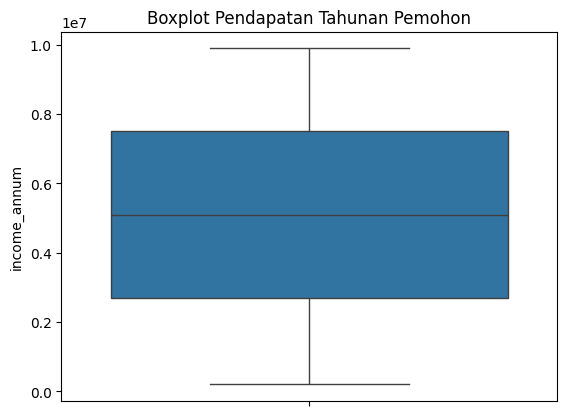

In [ ]:
# Boxplot Pendapatan Tahunan

sns.boxplot(y='income_annum', data=df)
plt.title('Boxplot Pendapatan Tahunan Pemohon')

plt.show()

**INTERPRETASI**

Berdasarkan boxplot, terlihat bahwa data pendapatan tahunan pemohon memiliki sebaran yang cukup luas, mulai dari pendapatan rendah hingga pendapatan tinggi. Nilai median berada di sekitar bagian tengah boxplot yang menunjukkan bahwa data relatif tersebar secara merata.

Selain itu, tidak terlihat adanya titik data yang berada di luar whisker sehingga tidak ditemukan outlier yang signifikan pada variabel income_annum. Hal ini menunjukkan bahwa sebagian besar data masih berada dalam rentang yang wajar dan tidak terdapat nilai ekstrem yang dapat memengaruhi analisis.

Dalam konteks analisis persetujuan pinjaman, variabel income_annum penting untuk diperhatikan karena pendapatan tahunan mencerminkan kemampuan finansial pemohon. Semakin tinggi pendapatan yang dimiliki, semakin besar kemungkinan pemohon memiliki kemampuan untuk memenuhi kewajiban pembayaran pinjaman sehingga berpotensi memengaruhi keputusan persetujuan pinjaman.

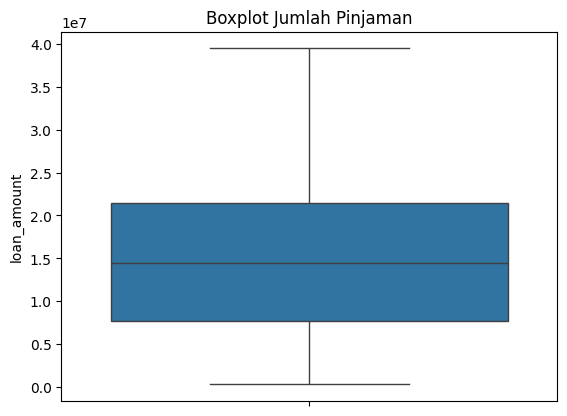

In [ ]:
# Boxplot Jumlah Pinjaman

sns.boxplot(data=df, y='loan_amount')
plt.title('Boxplot Jumlah Pinjaman')
plt.show()

**INTERPRETASI**

Berdasarkan boxplot, terlihat bahwa jumlah pinjaman yang diajukan pemohon memiliki rentang yang cukup luas, mulai dari nilai pinjaman yang rendah hingga tinggi. Nilai median berada di sekitar bagian tengah boxplot yang menunjukkan bahwa sebagian besar data tersebar di sekitar nilai tersebut.

Selain itu, tidak terlihat adanya titik data yang berada di luar whisker sehingga tidak ditemukan outlier yang signifikan pada variabel loan_amount. Hal ini menunjukkan bahwa sebagian besar nilai pinjaman masih berada dalam rentang yang wajar dan tidak terdapat nilai ekstrem yang dapat memengaruhi analisis.

Dalam konteks analisis persetujuan pinjaman, variabel loan_amount penting untuk diperhatikan karena besarnya pinjaman yang diajukan dapat memengaruhi keputusan persetujuan pinjaman. Semakin besar jumlah pinjaman yang diajukan, semakin besar pula risiko yang harus dipertimbangkan oleh lembaga keuangan dalam memberikan persetujuan pinjaman.

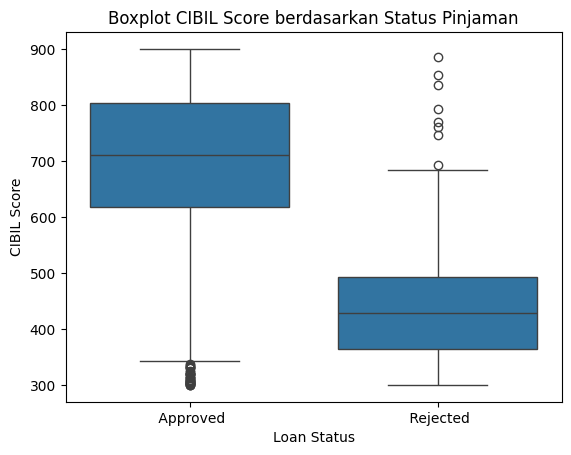

In [ ]:
# Boxplot CIBIL Score berdasarkan Status Pinjaman

sns.boxplot(data=df, x='loan_status', y='cibil_score')
plt.title('Boxplot CIBIL Score berdasarkan Status Pinjaman')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')

plt.show()

**INTERPRETASI**

Berdasarkan boxplot, terlihat bahwa pemohon dengan status pinjaman Approved memiliki CIBIL Score yang cenderung lebih tinggi dibandingkan pemohon dengan status Rejected. Nilai median CIBIL Score pada kelompok Approved berada di atas 700, sedangkan pada kelompok Rejected berada di sekitar 400.


Selain itu, terdapat perbedaan distribusi yang cukup jelas antara kedua kelompok. Sebagian besar pemohon yang mendapatkan persetujuan pinjaman memiliki skor kredit yang tinggi, sedangkan pemohon yang ditolak cenderung memiliki skor kredit yang lebih rendah. Meskipun terdapat beberapa outlier pada kedua kelompok, pola perbedaan antara Approved dan Rejected tetap terlihat dengan jelas.


Dalam konteks analisis persetujuan pinjaman, variabel CIBIL Score sangat penting karena mencerminkan riwayat dan kelayakan kredit pemohon. Semakin tinggi skor kredit yang dimiliki, semakin besar kemungkinan pemohon memperoleh persetujuan pinjaman. Oleh karena itu, CIBIL Score dapat menjadi salah satu variabel yang berpengaruh dalam proses klasifikasi status pinjaman.

Scatter Plot

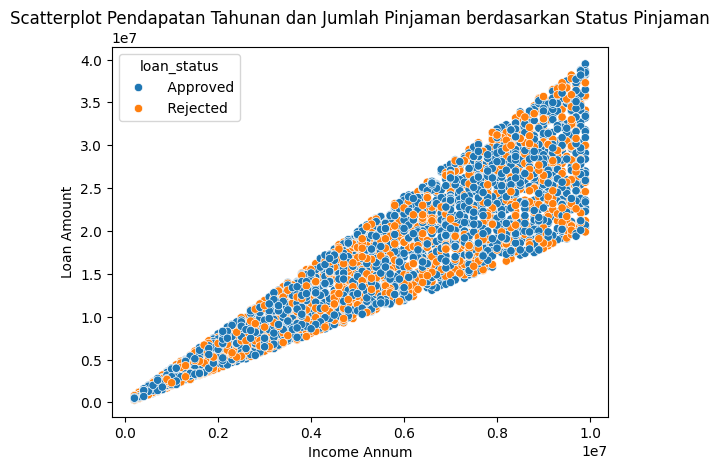

In [ ]:
# Scatterplot Income Annum vs Loan Amount berdasarkan Loan Status

sns.scatterplot(
    data=df,
    x='income_annum',
    y='loan_amount',
    hue='loan_status'
)

plt.title('Scatterplot Pendapatan Tahunan dan Jumlah Pinjaman berdasarkan Status Pinjaman')
plt.xlabel('Income Annum')
plt.ylabel('Loan Amount')

plt.show()

**INTERPRETASI**

Berdasarkan scatter plot, terlihat bahwa terdapat hubungan positif antara pendapatan tahunan (income_annum) dan jumlah pinjaman (loan_amount). Semakin tinggi pendapatan tahunan yang dimiliki pemohon, semakin besar pula jumlah pinjaman yang diajukan. Hal ini terlihat dari pola titik yang cenderung membentuk tren naik dari kiri bawah ke kanan atas.


Selain itu, berdasarkan warna kategori loan_status, data dengan status Approved dan Rejected tersebar pada berbagai rentang pendapatan maupun jumlah pinjaman. Meskipun demikian, jumlah data dengan status Approved terlihat lebih banyak dibandingkan Rejected pada sebagian besar rentang nilai.


Dalam konteks analisis persetujuan pinjaman, hubungan antara pendapatan tahunan dan jumlah pinjaman penting untuk diperhatikan karena kemampuan finansial pemohon dapat memengaruhi besarnya pinjaman yang diajukan. Variabel income_annum dan loan_amount berpotensi menjadi faktor yang berpengaruh dalam proses klasifikasi status pinjaman.

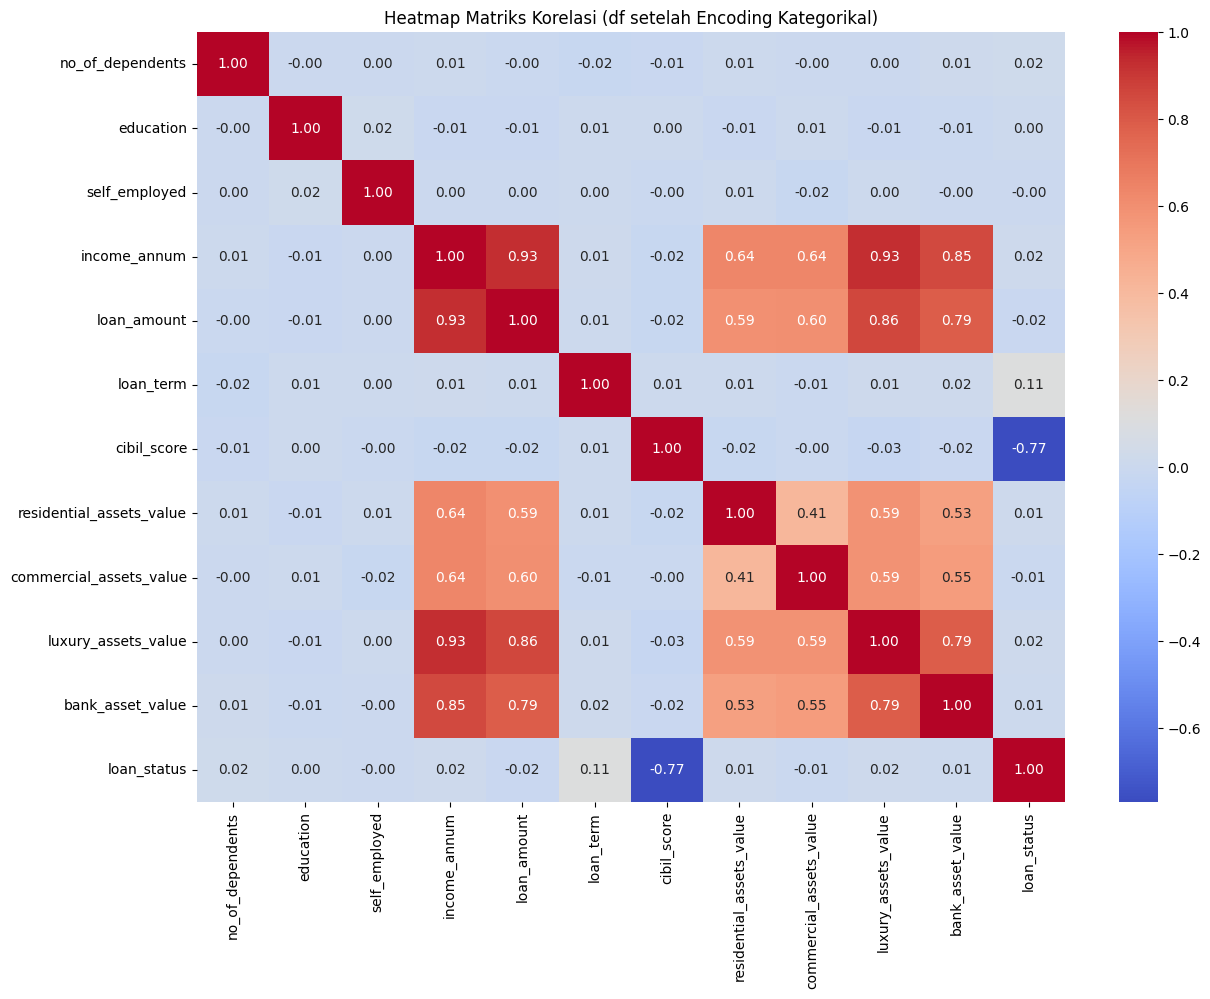

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Membuat salinan df
df_copy = df.copy()

# Membuat LabelEncoder
le = LabelEncoder()

# Mendapatkan kolom kategorikal dari df_copy
categorical_cols_copy = df_copy.select_dtypes(include='object').columns

# Melakukan encoding pada kolom kategorikal di df_copy
for col in categorical_cols_copy:
    df_copy[col] = le.fit_transform(df_copy[col])

# Menghitung matriks korelasi pada data yang sudah di-encode
correlation_matrix = df_copy.corr()

# Membuat heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Heatmap Matriks Korelasi (df setelah Encoding Kategorikal)')
plt.show()

**INTERPRETASI**

Berdasarkan heatmap matriks korelasi, sebagian besar variabel memiliki hubungan yang lemah dengan variabel loan_status. Namun, terdapat satu variabel yang menunjukkan hubungan yang cukup kuat, yaitu cibil_score dengan nilai korelasi sebesar -0.77.


Selain itu, terdapat korelasi positif yang kuat antara income_annum dan loan_amount sebesar 0.93. Korelasi yang tinggi juga terlihat antara income_annum dan luxury_assets_value sebesar 0.93, serta antara loan_amount dan luxury_assets_value sebesar 0.86. Hal ini menunjukkan bahwa pemohon dengan pendapatan yang lebih tinggi cenderung memiliki aset yang lebih besar dan mengajukan pinjaman dalam jumlah yang lebih besar.


Dalam konteks analisis persetujuan pinjaman, variabel cibil_score menjadi variabel yang paling berpengaruh terhadap status pinjaman karena memiliki korelasi paling kuat dengan loan_status. Oleh karena itu, cibil_score berpotensi menjadi salah satu variabel penting dalam proses klasifikasi persetujuan pinjaman.

c. Identifikasi Missing Value, Duplikat dan Outlier

Cek Missing Value

In [ ]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


**INTERPRETASI**

Tidak ada missing value

Cek Data Duplikat

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Memeriksa jumlah baris dan kolom dataset
print("Jumlah baris dan kolom:", df.shape)

# Menampilkan jumlah observasi
print("Jumlah data pemohon:", df.shape[0])

# Menampilkan jumlah variabel
print("Jumlah variabel:", df.shape[1])

Jumlah baris dan kolom: (4269, 12)
Jumlah data pemohon: 4269
Jumlah variabel: 12


**INTERPRETASI**

Berdasarkan hasil pemeriksaan dataset, terdapat 4.269 data pemohon pinjaman (observasi) dan 12 variabel yang digunakan dalam analisis. Jumlah data yang cukup banyak ini dapat memberikan informasi yang representatif untuk proses analisis dan pemodelan.


Selain itu, jumlah variabel yang tersedia mencakup karakteristik pemohon, kondisi keuangan, aset yang dimiliki, serta status pinjaman. Variabel-variabel tersebut dapat digunakan untuk mengidentifikasi faktor-faktor yang memengaruhi persetujuan pinjaman.


Dengan jumlah observasi dan variabel yang memadai, dataset ini dapat digunakan untuk membangun model klasifikasi dalam memprediksi status persetujuan pinjaman.

In [ ]:
# Memeriksa distribusi variabel target Loan Status
print("\nDistribusi variabel Loan Status:")
print(df["loan_status"].value_counts())

# Menampilkan persentase distribusi Loan Status
print("\nPersentase distribusi Loan Status:")
print(df["loan_status"].value_counts(normalize=True) * 100)


Distribusi variabel Loan Status:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Persentase distribusi Loan Status:
loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


**INTERPRETASI**

Berdasarkan hasil distribusi variabel target loan_status, terdapat 2.656 data dengan status pinjaman Approved dan 1.613 data dengan status pinjaman Rejected. Hal ini menunjukkan bahwa jumlah pinjaman yang disetujui lebih banyak dibandingkan pinjaman yang ditolak.


Berdasarkan persentase distribusinya, status Approved memiliki proporsi sebesar 62,22%, sedangkan status Rejected sebesar 37,78%. Dengan demikian, mayoritas data pada dataset merupakan pinjaman yang disetujui.


Deteksi Outlier

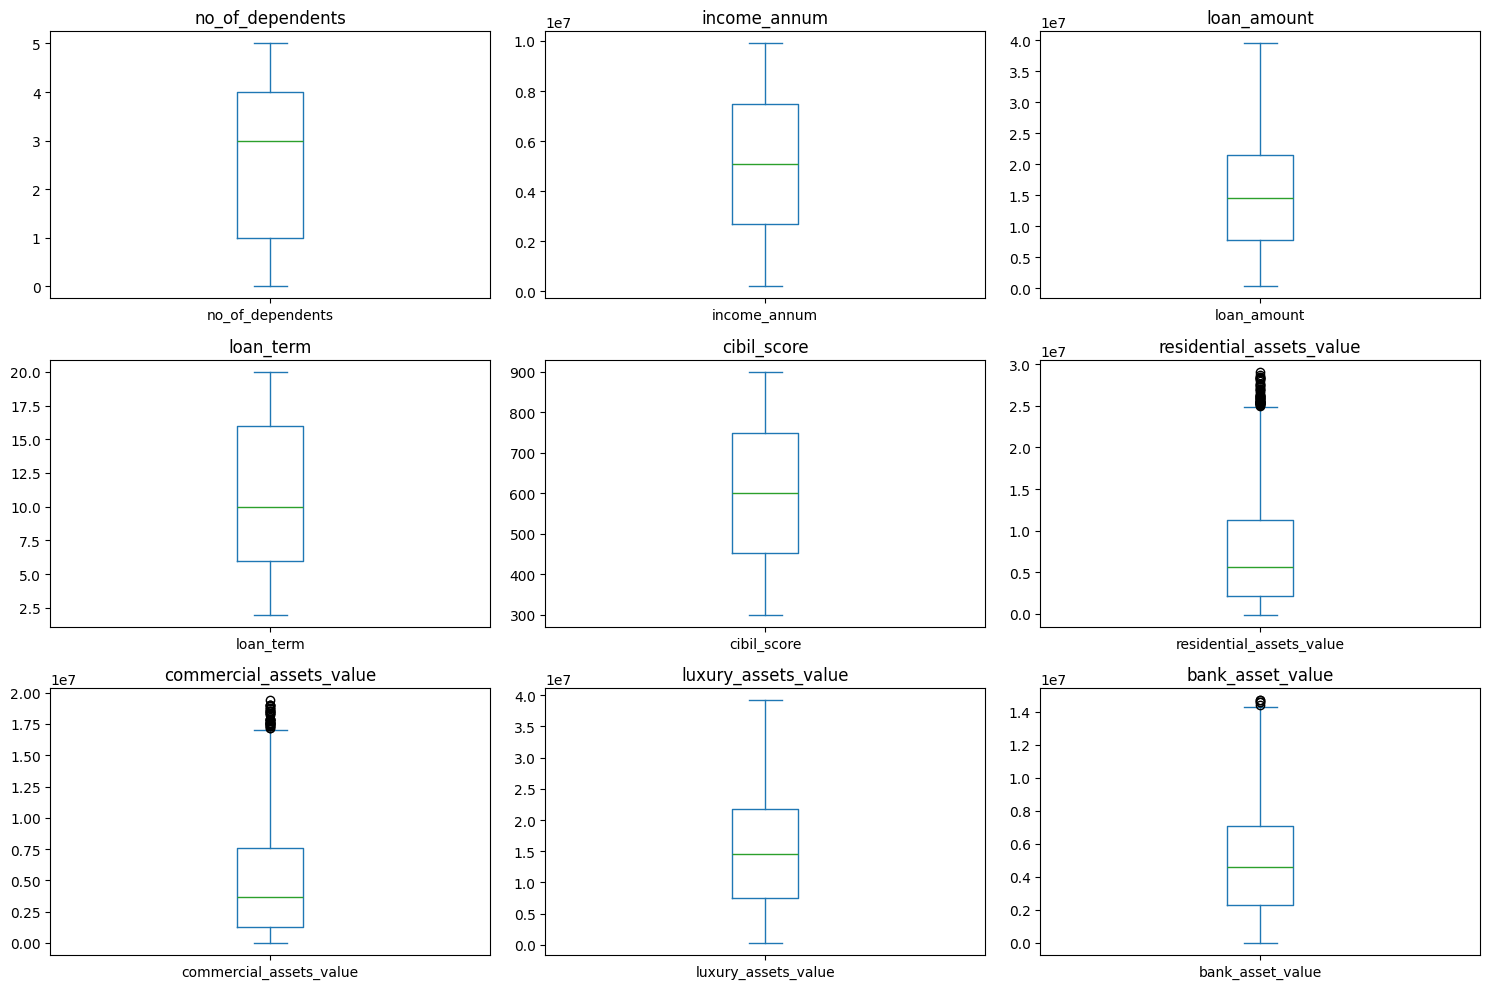

In [ ]:
# Menampilkan Boxplot Variabel Numerik

numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    df[col].plot(kind='box', ax=axes[i // 3, i % 3])
    axes[i // 3, i % 3].set_title(col)

plt.tight_layout()
plt.show()

**INTERPRETASI**

Berdasarkan boxplot seluruh variabel numerik, sebagian besar variabel memiliki sebaran data yang berada dalam rentang yang wajar. Variabel no_of_dependents, income_annum, loan_amount, loan_term, cibil_score, dan luxury_assets_value tidak menunjukkan adanya outlier.


Pada variabel residential_assets_value, commercial_assets_value, dan bank_asset_value terdapat beberapa data yang berada di luar batas whisker boxplot sehingga dapat dikategorikan sebagai outlier. Namun jumlah data tersebut relatif sedikit dibandingkan keseluruhan jumlah observasi dalam dataset.


Dalam konteks analisis persetujuan pinjaman, outlier yang ditemukan masih dapat diterima karena kemungkinan merepresentasikan pemohon yang memiliki nilai aset jauh lebih tinggi dibandingkan pemohon lainnya. Oleh karena itu, data outlier tidak dihapus dan tetap digunakan dalam proses analisis serta pemodelan.

In [ ]:
# Deteksi Outlier dengan IQR

numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}")
    print(f"Jumlah Outlier: {len(outliers)}")
    print("-" * 30)

no_of_dependents
Jumlah Outlier: 0
------------------------------
income_annum
Jumlah Outlier: 0
------------------------------
loan_amount
Jumlah Outlier: 0
------------------------------
loan_term
Jumlah Outlier: 0
------------------------------
cibil_score
Jumlah Outlier: 0
------------------------------
residential_assets_value
Jumlah Outlier: 52
------------------------------
commercial_assets_value
Jumlah Outlier: 37
------------------------------
luxury_assets_value
Jumlah Outlier: 0
------------------------------
bank_asset_value
Jumlah Outlier: 5
------------------------------


**INTERPRETASI**

Berdasarkan hasil deteksi outlier menggunakan metode Interquartile Range (IQR), sebagian besar variabel numerik tidak memiliki outlier. Variabel no_of_dependents, income_annum, loan_amount, loan_term, cibil_score, dan luxury_assets_value menunjukkan jumlah outlier sebanyak 0 data.

Namun, terdapat beberapa outlier pada variabel residential_assets_value sebanyak 52 data, commercial_assets_value sebanyak 37 data, dan bank_asset_value sebanyak 5 data. Outlier tersebut menunjukkan adanya beberapa pemohon yang memiliki nilai aset jauh lebih tinggi dibandingkan mayoritas pemohon lainnya.

Dalam konteks analisis persetujuan pinjaman, keberadaan outlier pada variabel aset masih dapat diterima karena kemungkinan merepresentasikan kondisi nyata di mana sebagian pemohon memiliki kekayaan atau aset yang jauh lebih besar dibandingkan pemohon lainnya. Oleh karena itu, outlier tidak dihapus dan tetap dipertahankan untuk proses analisis dan pemodelan selanjutnya.

# **3. Prapemrosesan dan Rekayasa Fitur**

Hapus Variabel yang Memiliki korelasi tinggi

In [ ]:
# drop variabel Luxury
# Tambahkan baris ini setelah proses pembersihan data selesai atau sebelum pembagian X dan y
df = df.drop(columns=['luxury_assets_value'])

a. Penanganan Outlier

In [ ]:
# ==========================================
# A. DROP BARIS OUTLIER UNTUK BANK_ASSET_VALUE
# ==========================================
Q1_bank = df['bank_asset_value'].quantile(0.25)
Q3_bank = df['bank_asset_value'].quantile(0.75)
IQR_bank = Q3_bank - Q1_bank

lower_bank = Q1_bank - 1.5 * IQR_bank
upper_bank = Q3_bank + 1.5 * IQR_bank

# Filter untuk membuang baris yang berada di luar batas (outlier)
df = df[(df['bank_asset_value'] >= lower_bank) & (df['bank_asset_value'] <= upper_bank)]


# ==========================================
# B. CAPPING OUTLIER RESIDENTIAL & COMMERCIAL
# ==========================================
cols_to_cap = ['residential_assets_value', 'commercial_assets_value']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping nilai ekstrem ke batas IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

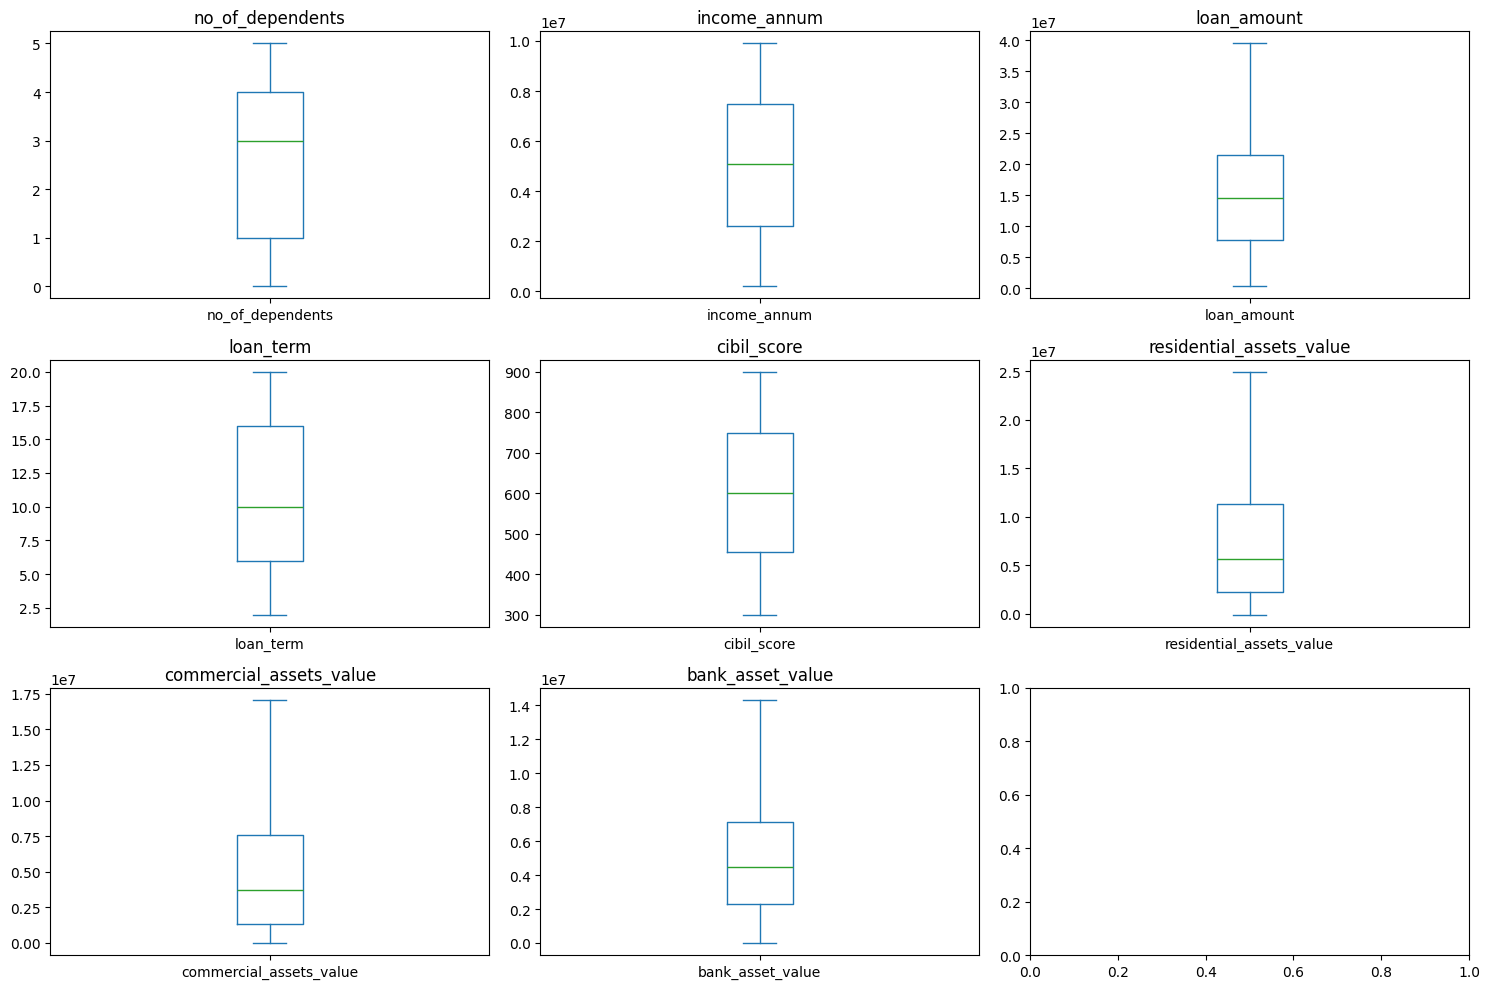

In [ ]:
# Menampilkan Boxplot Variabel Numerik

numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',

    'bank_asset_value'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    df[col].plot(kind='box', ax=axes[i // 3, i % 3])
    axes[i // 3, i % 3].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Deteksi Outlier dengan IQR

numerical_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'bank_asset_value'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}")
    print(f"Jumlah Outlier: {len(outliers)}")
    print("-" * 30)

no_of_dependents
Jumlah Outlier: 0
------------------------------
income_annum
Jumlah Outlier: 0
------------------------------
loan_amount
Jumlah Outlier: 0
------------------------------
loan_term
Jumlah Outlier: 0
------------------------------
cibil_score
Jumlah Outlier: 0
------------------------------
residential_assets_value
Jumlah Outlier: 0
------------------------------
commercial_assets_value
Jumlah Outlier: 0
------------------------------
bank_asset_value
Jumlah Outlier: 0
------------------------------


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4264 entries, 0 to 4268
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4264 non-null   int64  
 1   education                 4264 non-null   object 
 2   self_employed             4264 non-null   object 
 3   income_annum              4264 non-null   int64  
 4   loan_amount               4264 non-null   int64  
 5   loan_term                 4264 non-null   int64  
 6   cibil_score               4264 non-null   int64  
 7   residential_assets_value  4264 non-null   float64
 8   commercial_assets_value   4264 non-null   float64
 9   bank_asset_value          4264 non-null   int64  
 10  loan_status               4264 non-null   object 
dtypes: float64(2), int64(6), object(3)
memory usage: 399.8+ KB


In [ ]:
# Menampilkan jenis data

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4264 entries, 0 to 4268
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4264 non-null   int64  
 1   education                 4264 non-null   object 
 2   self_employed             4264 non-null   object 
 3   income_annum              4264 non-null   int64  
 4   loan_amount               4264 non-null   int64  
 5   loan_term                 4264 non-null   int64  
 6   cibil_score               4264 non-null   int64  
 7   residential_assets_value  4264 non-null   float64
 8   commercial_assets_value   4264 non-null   float64
 9   bank_asset_value          4264 non-null   int64  
 10  loan_status               4264 non-null   object 
dtypes: float64(2), int64(6), object(3)
memory usage: 399.8+ KB


b. Encoding Variabel Numerik

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000.0,17050000.0,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000.0,2200000.0,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000.0,4500000.0,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000.0,3300000.0,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000.0,8200000.0,5000000,1


c. Data Scaling

Normalisasi

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Memilih variabel numerik kontinu
kolom_normalisasi = [
    'income_annum',
    'loan_amount',
    'residential_assets_value',
    'commercial_assets_value',
    'bank_asset_value'
]

# Membuat objek scaler
scaler = MinMaxScaler()

# Menyalin dataframe hasil encoding
df_normalized = df.copy()

# Melakukan normalisasi
df_normalized[kolom_normalisasi] = scaler.fit_transform(
    df_normalized[kolom_normalisasi]
)

# Menampilkan hasil
df_normalized[kolom_normalisasi].head()

,income_annum,loan_amount,residential_assets_value,commercial_assets_value,bank_asset_value
0,0.969072,0.755102,0.099800,1.000000,0.559441
1,0.402062,0.303571,0.111776,0.129032,0.230769
2,0.917526,0.750000,0.287425,0.263930,0.895105
3,0.824742,0.775510,0.730539,0.193548,0.552448
4,0.989691,0.609694,0.499002,0.480938,0.349650


**INTERPRETASI**

Normalisasi dilakukan menggunakan metode Min-Max Scaling untuk mengubah rentang nilai variabel menjadi antara 0 dan 1. Proses ini bertujuan untuk menyamakan skala antar variabel sehingga fitur dengan nilai besar tidak mendominasi proses analisis maupun pemodelan.


Pada penelitian ini, normalisasi diterapkan pada seluruh variabel numerik kontinu yang berkaitan dengan pendapatan, pinjaman, skor kredit, dan nilai aset.

Standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

# Memilih kolom numerik kontinu
kolom_numerik = [
    'no_of_dependents',
    'cibil_score',
    'loan_term',
]

# Menghitung rata-rata dan standar deviasi
mean = df[kolom_numerik].mean()
std = df[kolom_numerik].std()

# Menerapkan standarisasi
df_standardized = df_normalized.copy()

df_standardized[kolom_numerik] = (
    df_normalized[kolom_numerik] - mean
) / std

# Menampilkan hasil
df_standardized[kolom_numerik].head()

,no_of_dependents,cibil_score,loan_term
0,-0.293827,1.031721,0.193428
1,-1.473562,-1.061786,-0.507615
2,0.296040,-0.545658,1.595514
3,0.296040,-0.771827,-0.507615
4,1.475775,-1.264758,1.595514


In [ ]:
df_standardized.head()


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,bank_asset_value,loan_status
0,-0.293827,0,0,0.969072,0.755102,0.193428,1.031721,0.099800,1.000000,0.559441,0
1,-1.473562,1,1,0.402062,0.303571,-0.507615,-1.061786,0.111776,0.129032,0.230769,1
2,0.296040,0,0,0.917526,0.750000,1.595514,-0.545658,0.287425,0.263930,0.895105,1
3,0.296040,0,0,0.824742,0.775510,-0.507615,-0.771827,0.730539,0.193548,0.552448,1
4,1.475775,1,1,0.989691,0.609694,1.595514,-1.264758,0.499002,0.480938,0.349650,1


**INTERPRETASI**

Standarisasi dilakukan dengan mengubah data sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Proses ini membantu menyamakan distribusi antar variabel dan mengurangi pengaruh perbedaan satuan pengukuran.


Standarisasi diterapkan pada seluruh variabel numerik kontinu agar setiap fitur memiliki skala yang sebanding sehingga dapat meningkatkan performa algoritma machine learning yang sensitif terhadap skala data.

d. Split Data

In [ ]:
from sklearn.model_selection import train_test_split

# Definisikan variabel target (y) dan fitur (X) menggunakan df_standardized

# Variabel target (y) adalah kolom 'loan_status'
y = df_standardized['loan_status']

# Variabel prediktor/fitur (X) adalah semua kolom

X = df_standardized.drop(['loan_status'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **4. PEMODELAN DATA**

Pembangunan Model

In [ ]:
# Import library untuk membagi data dan model klasifikasi

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier

**1. Logistik Regression**

In [ ]:
# --- Logistic Regression ---
print("\nTraining Logistic Regression...")

model_lr = LogisticRegression(
    random_state=42,
    solver='liblinear'
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("\n--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))


Training Logistic Regression...

--- Logistic Regression Performance ---
Accuracy: 0.9332
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       531
           1       0.93      0.89      0.91       322

    accuracy                           0.93       853
   macro avg       0.93      0.92      0.93       853
weighted avg       0.93      0.93      0.93       853



**2. Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Decision Tree ---
print("\nTraining Decision Tree...")

model_dt = DecisionTreeClassifier(
    random_state=42
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("\n--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))


Training Decision Tree...

--- Decision Tree Performance ---
Accuracy: 0.9859
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       322

    accuracy                           0.99       853
   macro avg       0.99      0.98      0.98       853
weighted avg       0.99      0.99      0.99       853



**3. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest ---
print("\nTraining Random Forest...")

model_rf = RandomForestClassifier(
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))


Training Random Forest...

--- Random Forest Performance ---
Accuracy: 0.9848
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       531
           1       1.00      0.96      0.98       322

    accuracy                           0.98       853
   macro avg       0.99      0.98      0.98       853
weighted avg       0.99      0.98      0.98       853



**4. XGBoost**

In [ ]:
from xgboost import XGBClassifier

# --- XGBoost ---
print("\nTraining XGBoost...")

model_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("\n--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))


Training XGBoost...

--- XGBoost Performance ---
Accuracy: 0.9894
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       531
           1       1.00      0.97      0.99       322

    accuracy                           0.99       853
   macro avg       0.99      0.99      0.99       853
weighted avg       0.99      0.99      0.99       853



# **5. EVALUASI DATA**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(['Approved','Rejected'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{np.str_('Approved'): np.int64(0), np.str_('Rejected'): np.int64(1)}


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate Logistic Regression
y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Evaluate Decision Tree Classifier
y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Evaluate Random Forest Classifier
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Evaluate XGBoost Classifier
y_pred_xgb = model_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

model_performance = {
    'Logistic Regression': accuracy_lr,
    'Decision Tree Classifier': accuracy_dt,
    'Random Forest Classifier': accuracy_rf,
    'XGBoost Classifier': accuracy_xgb
}

best_model_name = max(
    model_performance,
    key=model_performance.get
)

best_accuracy = model_performance[best_model_name]

print("\n### Ringkasan Kinerja Model:\n")

for model, accuracy in model_performance.items():
    print(f"* {model}: Accuracy = {accuracy:.4f}")

print(
    f"\nBerdasarkan hasil ini, {best_model_name} "
    f"adalah model terbaik dengan akurasi "
    f"{best_accuracy:.4f} pada data uji.\n"
)

print(
    f"\n--- Classification Report untuk "
    f"{best_model_name} ---"
)

if best_model_name == 'Logistic Regression':
    print(classification_report(y_test, y_pred_lr))

elif best_model_name == 'Decision Tree Classifier':
    print(classification_report(y_test, y_pred_dt))

elif best_model_name == 'Random Forest Classifier':
    print(classification_report(y_test, y_pred_rf))

elif best_model_name == 'XGBoost Classifier':
    print(classification_report(y_test, y_pred_xgb))


### Ringkasan Kinerja Model:

* Logistic Regression: Accuracy = 0.9332
* Decision Tree Classifier: Accuracy = 0.9859
* Random Forest Classifier: Accuracy = 0.9848
* XGBoost Classifier: Accuracy = 0.9894

Berdasarkan hasil ini, XGBoost Classifier adalah model terbaik dengan akurasi 0.9894 pada data uji.


--- Classification Report untuk XGBoost Classifier ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       531
           1       1.00      0.97      0.99       322

    accuracy                           0.99       853
   macro avg       0.99      0.99      0.99       853
weighted avg       0.99      0.99      0.99       853



                    Feature  Importance
6               cibil_score    0.639698
5                 loan_term    0.252494
3              income_annum    0.033080
4               loan_amount    0.027235
7  residential_assets_value    0.010899
8   commercial_assets_value    0.010437
0          no_of_dependents    0.007904
1                 education    0.007078
9          bank_asset_value    0.006411
2             self_employed    0.004764


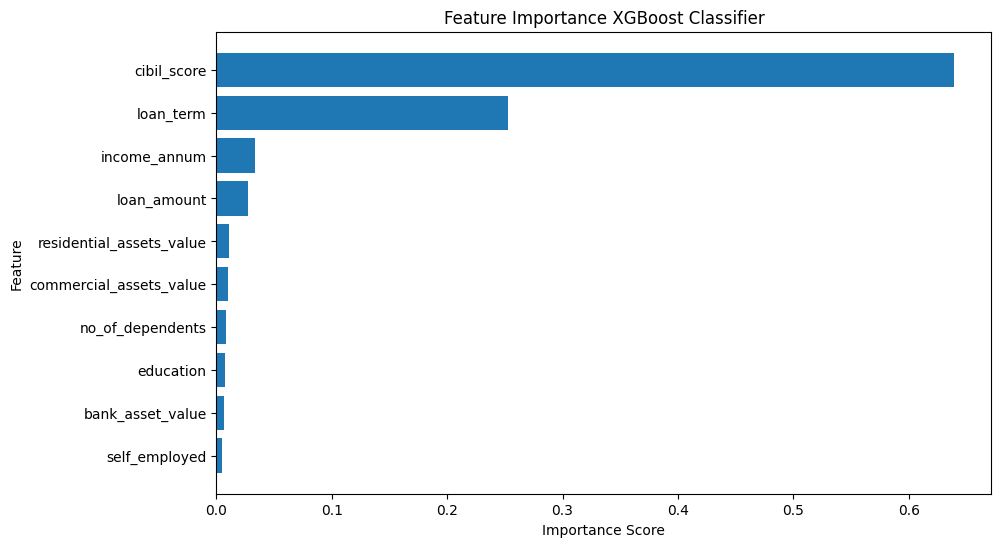

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance XGBoost Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.show()

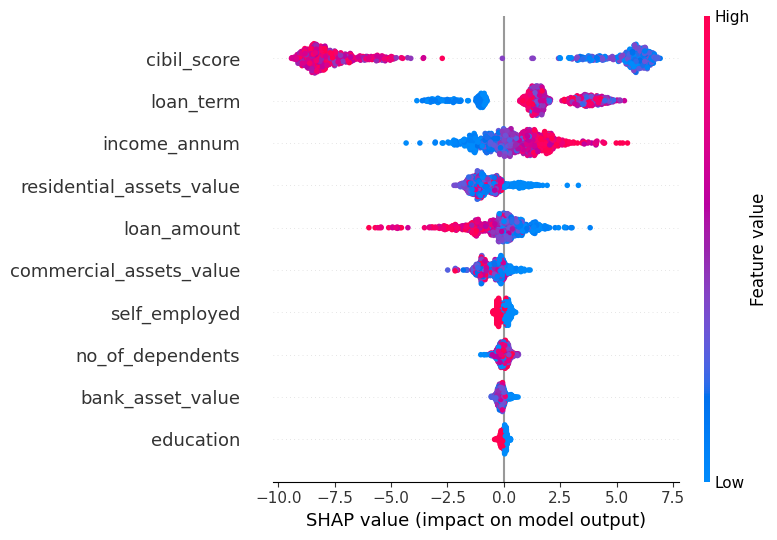

In [ ]:
# Install SHAP (jalankan sekali saja)
!pip install shap

import shap

# 'model_xgb' adalah model terbaik yang sudah dilatih sebelumnya

# Menghitung Skor SHAP
explainer = shap.TreeExplainer(model_xgb)

# shap_values untuk klasifikasi biner seringkali menghasilkan array 2D secara langsung (n_samples, n_features)
# atau daftar dua array [shap_values_class_0, shap_values_class_1].
# Berdasarkan error, 'shap_values' sepertinya sudah merupakan array 2D untuk kelas positif.
shap_values = explainer.shap_values(X_test)

# Menampilkan SHAP Summary Plot
# Jika shap_values adalah array 2D (n_samples, n_features), gunakan langsung.
# Jika shap_values adalah list dari array (untuk setiap kelas), gunakan shap_values[1] untuk kelas positif (jika ada).
# Berdasarkan konteks error, `shap_values` sudah merupakan matrix yang dibutuhkan.
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)


Hyperparameter Tuning

In [ ]:
# Import GridSearchCV untuk hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Definisikan grid parameter untuk XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("Memulai GridSearchCV untuk XGBoost...")

# Inisialisasi GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV ke data training
grid_search_xgb.fit(X_train, y_train)

print("GridSearchCV selesai.")

# Parameter terbaik
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"\nParameter terbaik untuk XGBoost: {best_params_xgb}")
print(f"Akurasi cross-validation terbaik untuk XGBoost: {best_score_xgb:.4f}")

# Model terbaik
best_model_xgb = grid_search_xgb.best_estimator_

# Prediksi data test
y_pred_xgb_tuned = best_model_xgb.predict(X_test)

print("\n--- Kinerja Tuned XGBoost Classifier pada Test Set ---")

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

Memulai GridSearchCV untuk XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV selesai.

Parameter terbaik untuk XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Akurasi cross-validation terbaik untuk XGBoost: 0.9850

--- Kinerja Tuned XGBoost Classifier pada Test Set ---
Accuracy: 0.9906
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       531
           1       1.00      0.98      0.99       322

    accuracy                           0.99       853
   macro avg       0.99      0.99      0.99       853
weighted avg       0.99      0.99      0.99       853



Model Final

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

# ==================================================
# KINERJA MODEL XGBOOST AWAL
# ==================================================

report_initial_xgb = classification_report(
    y_test,
    y_pred_xgb,
    output_dict=True
)

recall_initial_xgb = report_initial_xgb['1']['recall']

print("=== Kinerja XGBoost (Awal) ===")

print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Recall (Rejected Class): {recall_initial_xgb:.4f}")

# ==================================================
# KINERJA MODEL XGBOOST TUNED
# ==================================================

accuracy_tuned_xgb = accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

report_tuned_xgb = classification_report(
    y_test,
    y_pred_xgb_tuned,
    output_dict=True
)

recall_tuned_xgb = report_tuned_xgb['1']['recall']

print("\n=== Kinerja XGBoost (Tuned) ===")

print(f"Accuracy: {accuracy_tuned_xgb:.4f}")
print(f"Recall (Rejected Class): {recall_tuned_xgb:.4f}")

# ==================================================
# PERBANDINGAN
# ==================================================

print("\n--- Perbandingan ---")

print(
    f"Peningkatan Akurasi: "
    f"{(accuracy_tuned_xgb - accuracy_xgb):.4f}"
)

print(
    f"Peningkatan Recall (Rejected): "
    f"{(recall_tuned_xgb - recall_initial_xgb):.4f}"
)

=== Kinerja XGBoost (Awal) ===
Accuracy: 0.9894
Recall (Rejected Class): 0.9720

=== Kinerja XGBoost (Tuned) ===
Accuracy: 0.9906
Recall (Rejected Class): 0.9783

--- Perbandingan ---
Peningkatan Akurasi: 0.0012
Peningkatan Recall (Rejected): 0.0062


In [ ]:
# =====================================
# ANALISIS OVERFITTING / UNDERFITTING
# XGBOOST TUNED
# =====================================

from sklearn.metrics import accuracy_score

# Prediksi data training
y_train_pred = best_model_xgb.predict(X_train)

# Prediksi data testing
y_test_pred = best_model_xgb.predict(X_test)

# Accuracy training dan testing
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=== ANALISIS OVERFITTING / UNDERFITTING ===")

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

gap = abs(train_accuracy - test_accuracy)

print(f"Selisih Accuracy  : {gap:.4f}")

if gap > 0.05:
    print("\nKesimpulan: Model cenderung mengalami OVERFITTING")
elif train_accuracy < 0.80 and test_accuracy < 0.80:
    print("\nKesimpulan: Model cenderung mengalami UNDERFITTING")
else:
    print("\nKesimpulan: Model memiliki GENERALISASI yang baik")

=== ANALISIS OVERFITTING / UNDERFITTING ===
Training Accuracy : 0.9982
Testing Accuracy  : 0.9906
Selisih Accuracy  : 0.0076

Kesimpulan: Model memiliki GENERALISASI yang baik


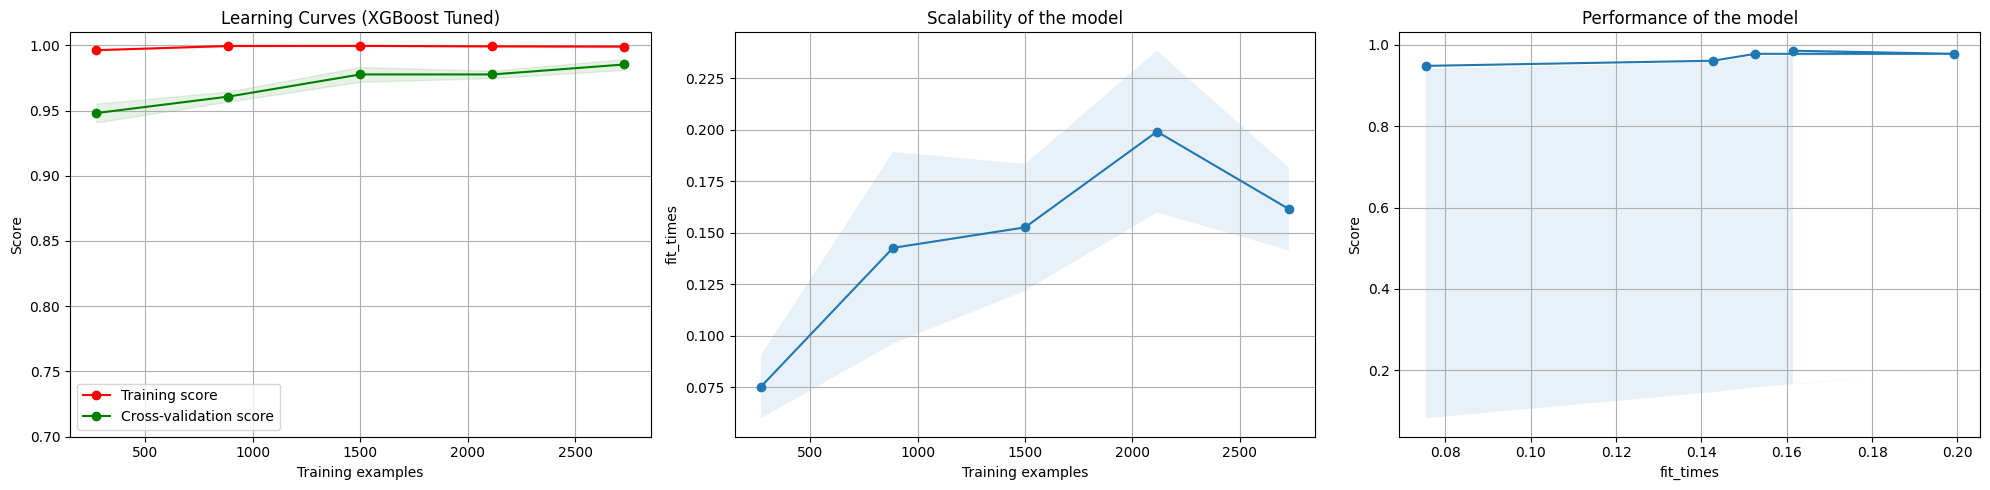

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing the "fit" and "predict" methods
        which will be cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        optional
        Target relative to X for classification or regression; None for
        unsupervised learning.

    axes : array-like, shape (3,), optional
        Axes to plot the curves on.

    ylim : tuple, shape (2,), optional
        Defines limits for the y-axis.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validation strategies that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``-1`` means using all processors.

    train_sizes : array-like, shape (n_ticks,),
        defaults to np.linspace(0.1, 1.0, 5)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes,
                       return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         fit_times_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt


# =====================================
# LEARNING CURVE XGBOOST TUNED
# =====================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_learning_curve(
    estimator=best_model_xgb,
    title="Learning Curves (XGBoost Tuned)",
    X=X_train,
    y=y_train,
    axes=axes,
    ylim=(0.7, 1.01),
    cv=5,
    n_jobs=-1
)

plt.tight_layout()
plt.show()